In [253]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# Load scoring JSON from MinneApple results
# results_dir = Path('/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple_v1/scoring/seed_123')
results_dir = Path('/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple_v2/scoring/seed_789')
preferred_names = {'score_results.json', 'scoring_results.json', 'detail_score.json'}

score_path = None
data = None

# Search for minneapple scoring results
for results_folder in results_dir.iterdir():
    if results_folder.is_dir() and 'minneapple' in results_folder.name.lower():
        step3_dir = results_folder 
        if step3_dir.exists():
            for fname in preferred_names:
                candidate = step3_dir / fname
                print(f"Checking for scoring file: {candidate}")
                if candidate.exists():
                    try:
                        with open(candidate, 'r', encoding='utf-8') as f:
                            d = json.load(f)
                        if isinstance(d, dict) and isinstance(d.get('image_difficulties'), list):
                            score_path = candidate
                            data = d
                            break
                    except Exception as e:
                        print(f"Failed to load {candidate}: {e}")
            if data:
                break

score_path = results_dir / 'score_results.json'  # Fallback to a common name if not found in subfolders
with open(score_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

if score_path is None:
    raise FileNotFoundError('No MinneApple scoring JSON with image_difficulties found')

image_difficulties = data['image_difficulties']
if len(image_difficulties) == 0:
    raise ValueError(f'Empty image_difficulties in {score_path}')

print(f'Loaded scoring file: {score_path}')
print(f'Number of images: {len(image_difficulties)}')

# Build object-level arrays (size vs object score)
obj_sizes = []
obj_scores = []
for img in image_difficulties:
    for obj in img.get('objects_score', []):
        bbox = obj.get('bounding_box', {})
        w = bbox.get('width')
        h = bbox.get('height')
        s = obj.get('difficulty_score')
        if w is None or h is None or s is None:
            continue
        obj_sizes.append(float(w) * float(h))
        obj_scores.append(float(s))

obj_sizes = np.array(obj_sizes, dtype=float)
obj_scores = np.array(obj_scores, dtype=float)

print(f'Total objects: {len(obj_scores)}')

Loaded scoring file: /home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple_v2/scoring/seed_789/score_results.json
Number of images: 630
Total objects: 26598


# MinneApple Score Pattern Analysis
Analyzing the correlation between object size and difficulty scores in the MinneApple dataset.

In [254]:
# Correlation analysis: object size vs object score
if len(obj_scores) < 2:
    raise ValueError('Not enough object samples to compute correlation.')

safe_sizes = np.clip(obj_sizes, 1e-8, None)

# Pearson correlation
pearson_obj = float(np.corrcoef(safe_sizes, obj_scores)[0, 1]) if not (np.allclose(safe_sizes, safe_sizes[0]) or np.allclose(obj_scores, obj_scores[0])) else float('nan')

# Spearman correlation using rank transform
def rankdata(arr):
    order = np.argsort(arr)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(arr), dtype=float)
    vals, inv, counts = np.unique(arr, return_inverse=True, return_counts=True)
    for i, c in enumerate(counts):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()
    return ranks + 1.0

spearman_obj = float(np.corrcoef(rankdata(safe_sizes), rankdata(obj_scores))[0, 1])

print('='*70)
print('CORRELATION: Object Size vs Object Difficulty Score')
print('='*70)
print(f'Pearson correlation:  {pearson_obj:.4f}')
print(f'Spearman correlation: {spearman_obj:.4f}')
print(f'Sample size: {len(obj_scores)}')
print()

CORRELATION: Object Size vs Object Difficulty Score
Pearson correlation:  -0.2646
Spearman correlation: -0.7934
Sample size: 26598



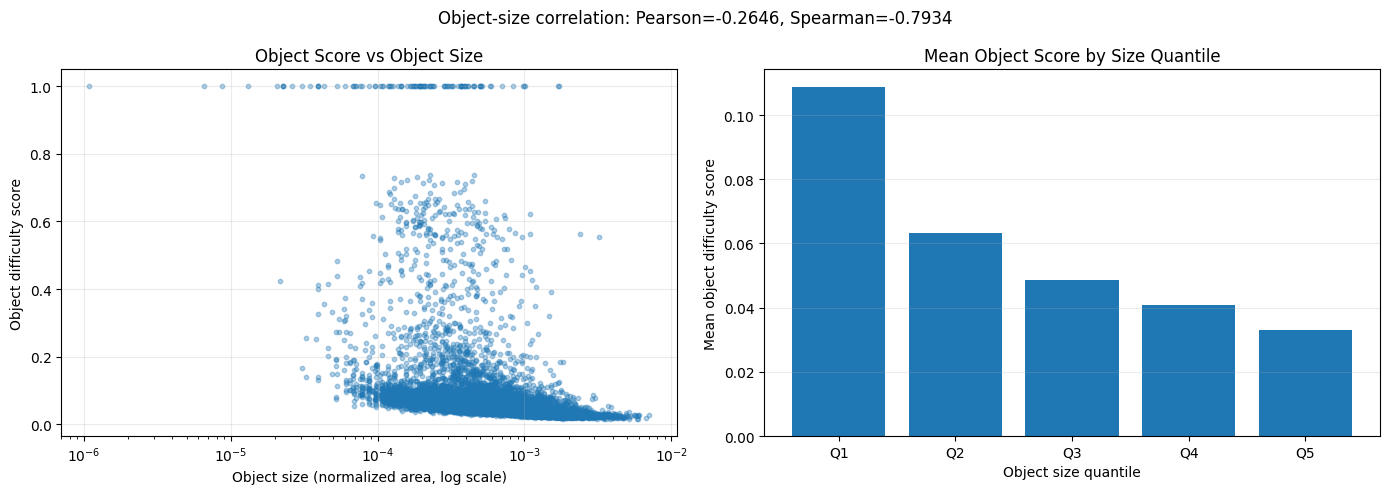

In [255]:
# Visualization: scatter plot and quantile analysis
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Scatter on log-size axis
ax[0].scatter(safe_sizes, obj_scores, s=10, alpha=0.35)
ax[0].set_xscale('log')
ax[0].set_xlabel('Object size (normalized area, log scale)')
ax[0].set_ylabel('Object difficulty score')
ax[0].set_title('Object Score vs Object Size')
ax[0].grid(alpha=0.25)

# Mean score by size quantile bins
q = np.quantile(safe_sizes, [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
for i in range(1, len(q)):
    if q[i] <= q[i - 1]:
        q[i] = q[i - 1] + 1e-12
bins = np.digitize(safe_sizes, q[1:-1], right=True)
means = [float(np.mean(obj_scores[bins == i])) if np.any(bins == i) else np.nan for i in range(5)]
ax[1].bar(['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], means)
ax[1].set_xlabel('Object size quantile')
ax[1].set_ylabel('Mean object difficulty score')
ax[1].set_title('Mean Object Score by Size Quantile')
ax[1].grid(axis='y', alpha=0.25)

fig.suptitle(f'Object-size correlation: Pearson={pearson_obj:.4f}, Spearman={spearman_obj:.4f}')
plt.tight_layout()
plt.show()

In [256]:
# Question 1 & 2: Analyze object size categories (small vs medium vs large)
# 
# Categories based on area (common in object detection):
# - Very Small:  area ≤ 20² = 400 pixels
# - Small: 20² < area < 32² = 1024 pixels  
# - Medium:  area ≥ 32² = 1024 pixels
#
# Note: obj_sizes are in normalized coordinates [0,1], so we need to know image dimensions
# MinneApple images are 720x1280 pixels

image_width = 720
image_height = 1280
image_area = image_width * image_height  # pixels
very_small_threshold = (20**2) / image_area  # normalized
small_threshold = (32**2) / image_area  # normalized

print('='*70)
print('SIZE CATEGORY THRESHOLDS')
print('='*70)
print(f'Image dimensions: {image_width}x{image_height} pixels (area={image_area})')
print(f'Very Small (area ≤ 400 px²):    normalized ≤ {very_small_threshold:.6f}')
print(f'Small (400 < area ≤ 1024 px²):   normalized in ({very_small_threshold:.6f}, {small_threshold:.6f})')
print(f'Medium (1024 < area ≤ 9216 px²): normalized > ({small_threshold:.6f}')
print()

# Classify objects
is_very_small = obj_sizes <= very_small_threshold
is_small = (obj_sizes > very_small_threshold) & (obj_sizes <= small_threshold)
is_medium = (obj_sizes > small_threshold) 

print(f'Distribution of objects by size category:')
print(f'  Very Small: {np.sum(is_very_small):6d} ({np.sum(is_very_small)/len(obj_sizes)*100:6.2f}%)')
print(f'  Small:  {np.sum(is_small):6d} ({np.sum(is_small)/len(obj_sizes)*100:6.2f}%)')
print(f'  Medium: {np.sum(is_medium):6d} ({np.sum(is_medium)/len(obj_sizes)*100:6.2f}%)')
print()

SIZE CATEGORY THRESHOLDS
Image dimensions: 720x1280 pixels (area=921600)
Very Small (area ≤ 400 px²):    normalized ≤ 0.000434
Small (400 < area ≤ 1024 px²):   normalized in (0.000434, 0.001111)
Medium (1024 < area ≤ 9216 px²): normalized > (0.001111

Distribution of objects by size category:
  Very Small:   6157 ( 23.15%)
  Small:   13338 ( 50.15%)
  Medium:   7103 ( 26.71%)



In [257]:
# ANSWER TO QUESTION 1:
# Of all objects with S_obj above 75th percentile, 
# what % are small, what % are medium?

p70 = np.percentile(obj_scores, 70)
above_p70 = obj_scores >= p70

print('='*70)
print('QUESTION 1: Among high-difficulty objects (S_obj ≥ 70th percentile)')
print('='*70)
print(f'70th percentile of S_obj: {p70:.4f}')
print(f'Number of objects ≥ 70th percentile: {np.sum(above_p70)}')
print()

# For objects above 70th percentile, compute percentages in each size category
high_diff_very_small = np.sum(is_very_small & above_p70)
high_diff_small = np.sum(is_small & above_p70)
high_diff_medium = np.sum(is_medium & above_p70)
total_high_diff = np.sum(above_p70)

if total_high_diff > 0:
    pct_very_small = (high_diff_very_small / total_high_diff) * 100
    pct_small = (high_diff_small / total_high_diff) * 100
    pct_medium = (high_diff_medium / total_high_diff) * 100

    print(f'Among high-difficulty objects:')
    print(f'  Very Small: {high_diff_very_small:6d} objects ({pct_very_small:6.2f}%)')
    print(f'  Small:  {high_diff_small:6d} objects ({pct_small:6.2f}%)')
    print(f'  Medium: {high_diff_medium:6d} objects ({pct_medium:6.2f}%)')
    print()
else:
    print('No objects found above 75th percentile')
    pct_very_small = pct_small = pct_medium = 0

QUESTION 1: Among high-difficulty objects (S_obj ≥ 70th percentile)
70th percentile of S_obj: 0.0530
Number of objects ≥ 70th percentile: 7980

Among high-difficulty objects:
  Very Small:   4799 objects ( 60.14%)
  Small:    2938 objects ( 36.82%)
  Medium:    243 objects (  3.05%)



In [258]:
# ANSWER TO QUESTION 2:
# What is the mean S_obj for small vs medium objects?

print('='*70)
print('QUESTION 2: Mean S_obj by size category')
print('='*70)

mean_score_very_small = np.mean(obj_scores[is_very_small]) if np.sum(is_very_small) > 0 else np.nan
mean_score_small = np.mean(obj_scores[is_small]) if np.sum(is_small) > 0 else np.nan
mean_score_medium = np.mean(obj_scores[is_medium]) if np.sum(is_medium) > 0 else np.nan

std_score_very_small = np.std(obj_scores[is_very_small]) if np.sum(is_very_small) > 0 else np.nan
std_score_small = np.std(obj_scores[is_small]) if np.sum(is_small) > 0 else np.nan
std_score_medium = np.std(obj_scores[is_medium]) if np.sum(is_medium) > 0 else np.nan

print(f'Very Small objects:')
print(f'  Count: {np.sum(is_very_small)}, Mean S_obj: {mean_score_very_small:.4f}, Std: {std_score_very_small:.4f}')
print()
print(f'Small objects:')
print(f'  Count: {np.sum(is_small)}, Mean S_obj: {mean_score_small:.4f}, Std: {std_score_small:.4f}')
print()
print(f'Medium objects:')
print(f'  Count: {np.sum(is_medium)}, Mean S_obj: {mean_score_medium:.4f}, Std: {std_score_medium:.4f}')
print()
# print(f'Large objects:')
# print(f'  Count: {np.sum(is_large)}, Mean S_obj: {mean_score_large:.4f}, Std: {std_score_large:.4f}')
# print()

QUESTION 2: Mean S_obj by size category
Very Small objects:
  Count: 6157, Mean S_obj: 0.1034, Std: 0.1422

Small objects:
  Count: 13338, Mean S_obj: 0.0516, Std: 0.0508

Medium objects:
  Count: 7103, Mean S_obj: 0.0345, Std: 0.0234



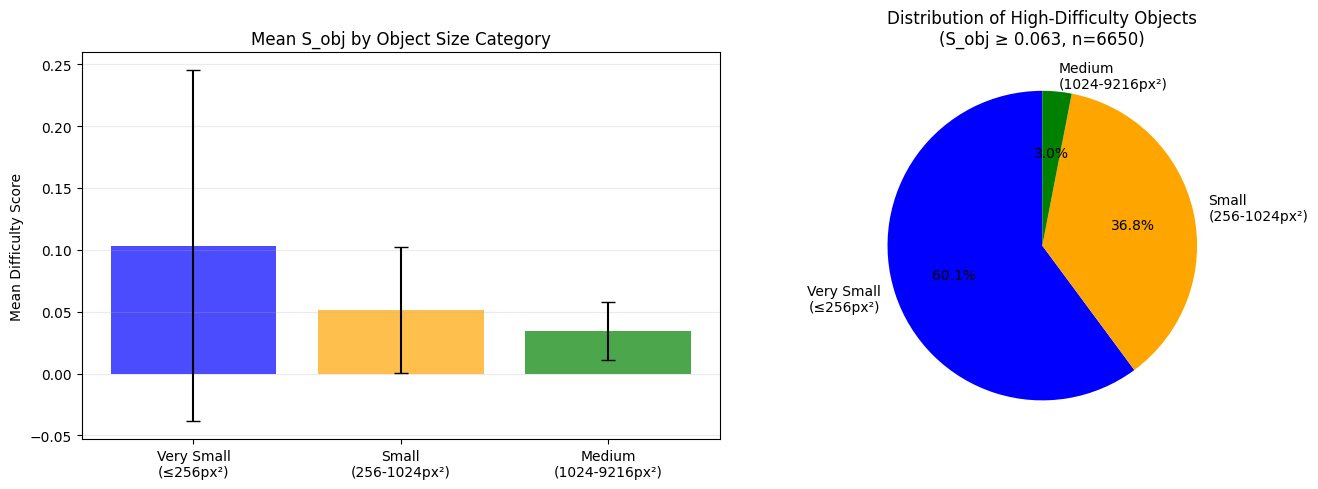

In [259]:
# Visualization: Compare mean scores across size categories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of mean scores
categories = ['Very Small\n(≤256px²)', 'Small\n(256-1024px²)', 'Medium\n(1024-9216px²)']
means = [mean_score_very_small, mean_score_small, mean_score_medium]
stds = [std_score_very_small, std_score_small, std_score_medium]

axes[0].bar(categories, means, yerr=stds, capsize=5, alpha=0.7, color=['blue', 'orange', 'green'])
axes[0].set_ylabel('Mean Difficulty Score')
axes[0].set_title('Mean S_obj by Object Size Category')
axes[0].grid(axis='y', alpha=0.25)

# Distribution of high-difficulty objects by size category
high_diff_pcts = [pct_very_small,pct_small, pct_medium]
colors = ['blue', 'orange', 'green']
axes[1].pie(high_diff_pcts, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(f'Distribution of High-Difficulty Objects\n(S_obj ≥ {p75:.3f}, n={np.sum(above_p75)})')

plt.tight_layout()
plt.show()

## Object Size Category Distribution (MinneApple)
This section reports how object sizes are distributed in pixel scale.

- Fixed bins: `<16`, `16-32`, `32-64`, `64-96`, `96-128`, `>=128` (square-root area in pixels).
- Quartile bins: `Q1-Q4`, each containing about 25% of objects.

MINNEAPPLE OBJECT SIZE DISTRIBUTION
Total objects: 26598
Side-length proxy sqrt(area): min=1.00px, median=26.27px, max=80.78px

Fixed bins (% of all objects):
      <16:    2534 (  9.53%)
    16-32:   16961 ( 63.77%)
    32-64:    7076 ( 26.60%)
    64-96:      27 (  0.10%)
   96-128:       0 (  0.00%)
    >=128:       0 (  0.00%)

Quartile bins (size ranges that split data into ~25% each):
  Q1: [1.00, 20.49] px ->    6621 ( 24.89%)
  Q2: [20.49, 26.27] px ->    6656 ( 25.02%)
  Q3: [26.27, 32.50] px ->    6624 ( 24.90%)
  Q4: [32.50, 80.78] px ->    6697 ( 25.18%)


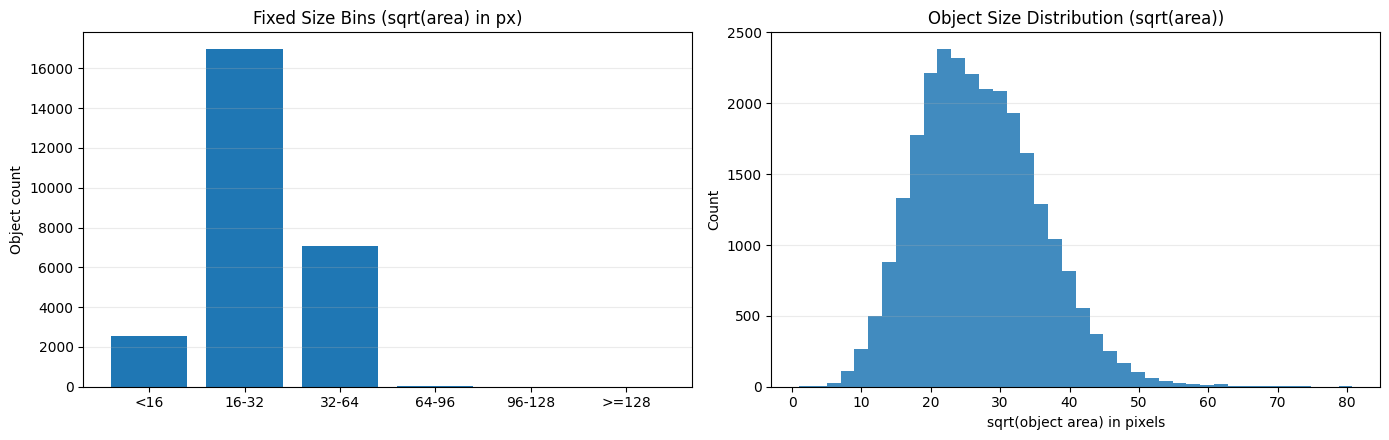

In [260]:
from PIL import Image

# Build per-image resolution map to convert normalized bbox area to pixel area
image_area_map = {}
for img in image_difficulties:
    p = img.get('image_path', '')
    if not p or p in image_area_map:
        continue
    try:
        with Image.open(p) as im:
            w, h = im.size
        image_area_map[p] = float(w * h)
    except Exception:
        # Fallback to known MinneApple size used in this notebook
        image_area_map[p] = float(image_width * image_height)

# Convert normalized object area to pixel area and side length scale sqrt(area)
obj_area_px = []
for img in image_difficulties:
    img_path = img.get('image_path', '')
    area_img = image_area_map.get(img_path, float(image_width * image_height))
    for obj in img.get('objects_score', []):
        bbox = obj.get('bounding_box', {})
        bw = bbox.get('width')
        bh = bbox.get('height')
        if bw is None or bh is None:
            continue
        a_norm = float(bw) * float(bh)
        obj_area_px.append(a_norm * area_img)

obj_area_px = np.asarray(obj_area_px, dtype=float)
obj_side_px = np.sqrt(np.clip(obj_area_px, 0.0, None))

if obj_side_px.size == 0:
    raise ValueError('No object sizes found to compute distribution.')

print('=' * 78)
print('MINNEAPPLE OBJECT SIZE DISTRIBUTION')
print('=' * 78)
print(f'Total objects: {obj_side_px.size}')
print(f'Side-length proxy sqrt(area): min={obj_side_px.min():.2f}px, median={np.median(obj_side_px):.2f}px, max={obj_side_px.max():.2f}px')
print()

# 1) Fixed size bins
fixed_edges = np.array([0, 16, 32, 64, 96, 128, np.inf], dtype=float)
fixed_labels = ['<16', '16-32', '32-64', '64-96', '96-128', '>=128']
fixed_counts = []
for i in range(len(fixed_edges) - 1):
    left = fixed_edges[i]
    right = fixed_edges[i + 1]
    if np.isinf(right):
        m = obj_side_px >= left
    else:
        m = (obj_side_px >= left) & (obj_side_px < right)
    fixed_counts.append(int(np.sum(m)))

print('Fixed bins (% of all objects):')
for lab, c in zip(fixed_labels, fixed_counts):
    pct = 100.0 * c / obj_side_px.size
    print(f'  {lab:>7s}: {c:7d} ({pct:6.2f}%)')
print()

# 2) Quartiles (about 25% each)
q_edges = np.quantile(obj_side_px, [0.0, 0.25, 0.5, 0.75, 1.0])
for i in range(1, len(q_edges)):
    if q_edges[i] <= q_edges[i - 1]:
        q_edges[i] = q_edges[i - 1] + 1e-9

q_counts = []
for i in range(4):
    if i < 3:
        m = (obj_side_px >= q_edges[i]) & (obj_side_px < q_edges[i + 1])
    else:
        m = (obj_side_px >= q_edges[i]) & (obj_side_px <= q_edges[i + 1])
    q_counts.append(int(np.sum(m)))

print('Quartile bins (size ranges that split data into ~25% each):')
for i in range(4):
    l = q_edges[i]
    r = q_edges[i + 1]
    pct = 100.0 * q_counts[i] / obj_side_px.size
    print(f'  Q{i+1}: [{l:.2f}, {r:.2f}] px -> {q_counts[i]:7d} ({pct:6.2f}%)')

# Quick chart
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(fixed_labels, fixed_counts)
ax[0].set_title('Fixed Size Bins (sqrt(area) in px)')
ax[0].set_ylabel('Object count')
ax[0].grid(axis='y', alpha=0.25)

ax[1].hist(obj_side_px, bins=40, alpha=0.85)
ax[1].set_title('Object Size Distribution (sqrt(area))')
ax[1].set_xlabel('sqrt(object area) in pixels')
ax[1].set_ylabel('Count')
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

LEARNABLE ZONE ANALYSIS
Resolution floor: 400 px²
Mastered threshold (25th percentile): 0.0352
High difficulty ceiling (75th percentile): 0.0563

Total objects: 26598
Objects in learnable zone: 11442
Percentage: 43.02%

Learnable objects by size category:
  Very Small:      0 (0.00% of learnable)
  Small:        9448 (82.57% of learnable)
  Medium:       1994 (17.43% of learnable)



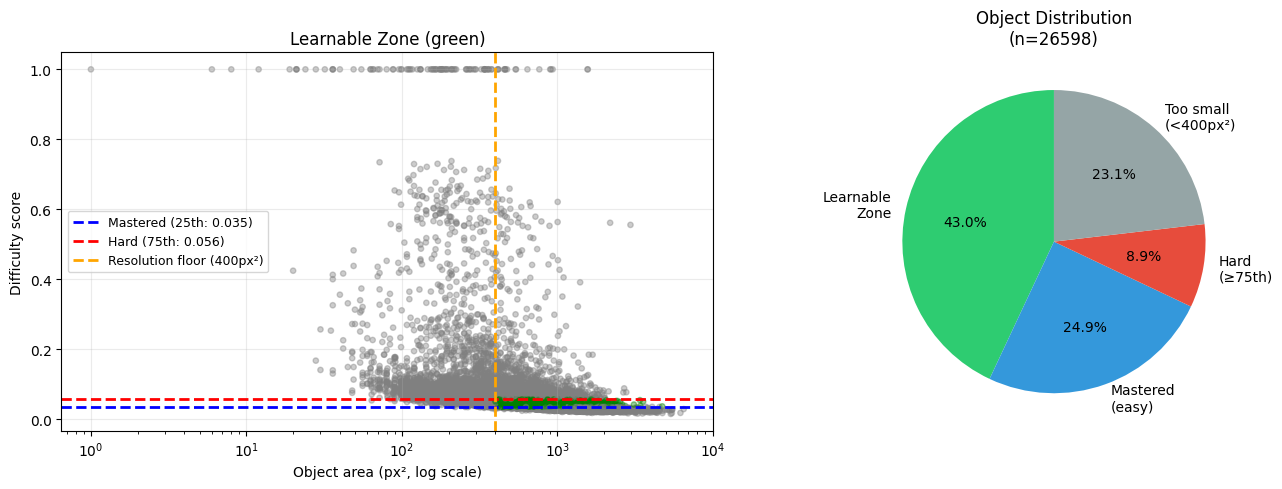

In [261]:
# What percentage of MinneApple objects are in the 
# "learnable zone" — above resolution floor AND 
# not already mastered by baseline?

resolution_floor = 400  # pixels²
p25 = np.percentile(obj_scores, 25)  # mastered_threshold (low difficulty)
p75 = np.percentile(obj_scores, 75)  # high difficulty ceiling

print('='*70)
print('LEARNABLE ZONE ANALYSIS')
print('='*70)
print(f'Resolution floor: {resolution_floor} px²')
print(f'Mastered threshold (25th percentile): {p25:.4f}')
print(f'High difficulty ceiling (75th percentile): {p75:.4f}')
print()

# Find objects in the learnable zone:
# - Above resolution floor (resolvable by model)
# - Above mastered threshold (not already easy)
# - Below 75th percentile (room to improve)
learnable_mask = (
    (obj_area_px > resolution_floor) &  # resolvable
    (obj_scores > p25) &  # not already mastered
    (obj_scores < p75)    # not already hard
)

learnable_count = np.sum(learnable_mask)
total_count = len(obj_scores)
learnable_pct = (learnable_count / total_count) * 100

print(f'Total objects: {total_count}')
print(f'Objects in learnable zone: {learnable_count}')
print(f'Percentage: {learnable_pct:.2f}%')
print()

# Breakdown: where are learnable objects in size distribution?
learnable_very_small = np.sum(learnable_mask & is_very_small)
learnable_small = np.sum(learnable_mask & is_small)
learnable_medium = np.sum(learnable_mask & is_medium)

print(f'Learnable objects by size category:')
print(f'  Very Small: {learnable_very_small:6d} ({100*learnable_very_small/max(learnable_count, 1):.2f}% of learnable)')
print(f'  Small:      {learnable_small:6d} ({100*learnable_small/max(learnable_count, 1):.2f}% of learnable)')
print(f'  Medium:     {learnable_medium:6d} ({100*learnable_medium/max(learnable_count, 1):.2f}% of learnable)')
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: all objects colored by learnable status
colors_map = np.where(learnable_mask, 'green', 'gray')
axes[0].scatter(obj_area_px, obj_scores, c=colors_map, s=15, alpha=0.4)
axes[0].axhline(y=p25, color='blue', linestyle='--', linewidth=2, label=f'Mastered (25th: {p25:.3f})')
axes[0].axhline(y=p75, color='red', linestyle='--', linewidth=2, label=f'Hard (75th: {p75:.3f})')
axes[0].axvline(x=resolution_floor, color='orange', linestyle='--', linewidth=2, label=f'Resolution floor ({resolution_floor}px²)')
axes[0].set_xscale('log')
axes[0].set_xlabel('Object area (px², log scale)')
axes[0].set_ylabel('Difficulty score')
axes[0].set_title('Learnable Zone (green)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

# Pie chart: learnable vs others
learnable_labels = ['Learnable\nZone', 'Mastered\n(easy)', 'Hard\n(≥75th)', 'Too small\n(<400px²)']
mastered = np.sum((obj_area_px > resolution_floor) & (obj_scores <= p25))
hard = np.sum((obj_area_px > resolution_floor) & (obj_scores >= p75))
too_small = np.sum(obj_area_px <= resolution_floor)
learnable_labels_data = [learnable_count, mastered, hard, too_small]
colors_pie = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
axes[1].pie(learnable_labels_data, labels=learnable_labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1].set_title(f'Object Distribution\n(n={total_count})')

plt.tight_layout()
plt.show()
